In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib
import os

sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


In [2]:
# Load processed data
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

# Load RF model for stacking
rf_model = joblib.load('../models/random_forest_model.pkl')

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')
print('RF model loaded')

Train: (733693, 39)
Test:  (183424, 39)
RF model loaded


In [3]:
# Stacking — get RF probability predictions
print('Getting RF predictions for stacking...')

rf_train_preds = rf_model.predict_proba(X_train)[:, 1]
rf_test_preds  = rf_model.predict_proba(X_test)[:, 1]

# Stack RF predictions with original features
X_train_stacked = np.column_stack([X_train, rf_train_preds])
X_test_stacked  = np.column_stack([X_test,  rf_test_preds])

print(f'Stacked train shape: {X_train_stacked.shape}')
print(f'Stacked test shape:  {X_test_stacked.shape}')

Getting RF predictions for stacking...
Stacked train shape: (733693, 40)
Stacked test shape:  (183424, 40)


In [4]:
# Train XGBoost on stacked features
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Class ratio: {scale_pos_weight:.2f}')
print('Training XGBoost... (this takes 1-3 minutes)')

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_stacked, y_train)
print('Training complete')

Class ratio: 1.42
Training XGBoost... (this takes 1-3 minutes)
Training complete


In [5]:
# Predictions and metrics
y_pred = xgb_model.predict(X_test_stacked)
y_prob = xgb_model.predict_proba(X_test_stacked)[:, 1]

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

fpr_score = FP / (FP + TN) if (FP + TN) > 0 else 0
fnr_score = FN / (FN + TP) if (FN + TP) > 0 else 0
accuracy  = (TP + TN) / len(y_test)

print('=== Stacked XGBoost Results ===')
print(f'True Positives:      {TP:,}')
print(f'True Negatives:      {TN:,}')
print(f'False Positives:     {FP:,}')
print(f'False Negatives:     {FN:,}')
print(f'\nFalse Positive Rate: {fpr_score:.4f} ({fpr_score*100:.2f}%)')
print(f'Accuracy:            {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'\n{classification_report(y_test, y_pred, target_names=["Normal", "Attack"])}')

=== Stacked XGBoost Results ===
True Positives:      75,843
True Negatives:      107,301
False Positives:     173
False Negatives:     107

False Positive Rate: 0.0016 (0.16%)
Accuracy:            0.9985 (99.85%)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    107474
      Attack       1.00      1.00      1.00     75950

    accuracy                           1.00    183424
   macro avg       1.00      1.00      1.00    183424
weighted avg       1.00      1.00      1.00    183424



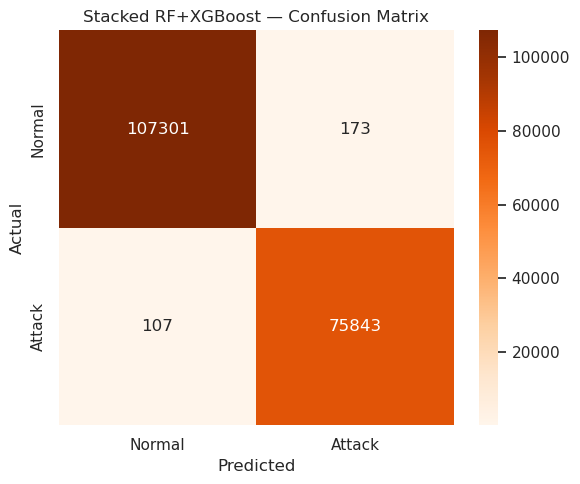

Saved


In [6]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Stacked RF+XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_stacked.png', dpi=150)
plt.show()
print('Saved')

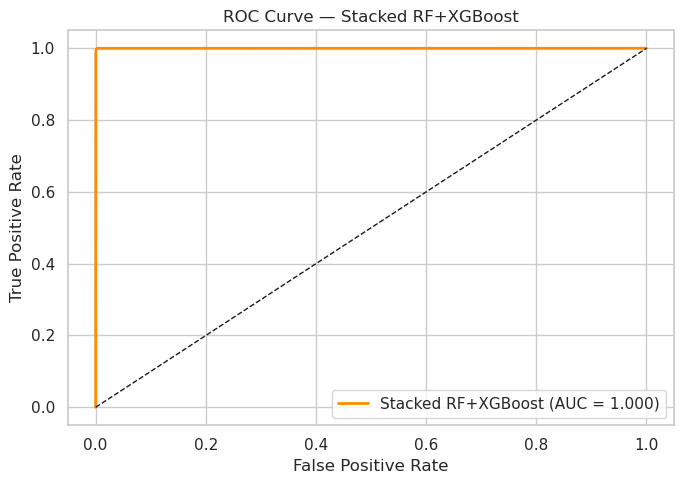

AUC Score: 1.0000


In [7]:
# ROC Curve
fpr_roc, tpr_roc, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(7, 5))
plt.plot(fpr_roc, tpr_roc, label=f'Stacked RF+XGBoost (AUC = {roc_auc:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Stacked RF+XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/roc_curve_stacked.png', dpi=150)
plt.show()
print(f'AUC Score: {roc_auc:.4f}')

In [8]:
# Save model and metrics
joblib.dump(xgb_model, '../models/xgboost_stacked_model.pkl')

results_path = '../results/metrics/results_summary.csv'
existing = pd.read_csv(results_path)
new_row = pd.DataFrame([{
    'Model': 'Stacked RF+XGBoost',
    'Accuracy': round(accuracy, 4),
    'False Positive Rate': round(fpr_score, 4),
    'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
}])
pd.concat([existing, new_row]).to_csv(results_path, index=False)
print('Model saved to models/xgboost_stacked_model.pkl')
print('Metrics saved to results_summary.csv')

Model saved to models/xgboost_stacked_model.pkl
Metrics saved to results_summary.csv


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import joblib
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load stacked test data
rf_model  = joblib.load('../models/random_forest_model.pkl')
xgb_model = joblib.load('../models/xgboost_stacked_model.pkl')
scaler    = joblib.load('../models/scaler.pkl')

X_train_orig = np.load('../data/processed/X_train.npy')
y_train_orig = np.load('../data/processed/y_train.npy')

# Sample 50,000 rows
sample_size = 50000
idx      = np.random.choice(len(X_train_orig), sample_size, replace=False)
X_sample = X_train_orig[idx]
y_sample = y_train_orig[idx]

# Create stacked features
rf_probs  = rf_model.predict_proba(X_sample)[:, 1]
X_stacked = np.column_stack([X_sample, rf_probs])

print('Running 3-Fold Cross Validation on Stacked XGBoost...')

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracy  = cross_val_score(xgb_model, X_stacked, y_sample, cv=kfold, scoring='accuracy',  n_jobs=-1)
cv_precision = cross_val_score(xgb_model, X_stacked, y_sample, cv=kfold, scoring='precision', n_jobs=-1)
cv_recall    = cross_val_score(xgb_model, X_stacked, y_sample, cv=kfold, scoring='recall',    n_jobs=-1)
cv_f1        = cross_val_score(xgb_model, X_stacked, y_sample, cv=kfold, scoring='f1',        n_jobs=-1)

print('=== 3-Fold Cross Validation Results — Stacked XGBoost ===')
print(f'Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}')
print(f'Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}')
print(f'Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}')
print(f'F1 Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

# Save results
cv_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Mean':   [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), cv_f1.mean()],
    'Std':    [cv_accuracy.std(), cv_precision.std(), cv_recall.std(), cv_f1.std()]
})
cv_results['Mean'] = cv_results['Mean'].round(4)
cv_results['Std']  = cv_results['Std'].round(4)
cv_results.to_csv('../results/metrics/cv_results_xgb.csv', index=False)
print('\nResults saved to cv_results_xgb.csv')

Running 3-Fold Cross Validation on Stacked XGBoost...
=== 3-Fold Cross Validation Results — Stacked XGBoost ===
Accuracy:  0.9985 ± 0.0001
Precision: 0.9974 ± 0.0002
Recall:    0.9989 ± 0.0004
F1 Score:  0.9982 ± 0.0002

Results saved to cv_results_xgb.csv


In [2]:
from sklearn.model_selection import train_test_split

# Reload the raw data the same way 02_preprocessing.ipynb did
data_path = '../data/raw/'
files = [
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
]
dfs = []
for f in files:
    path = data_path + f
    temp = pd.read_csv(path, low_memory=False)
    dfs.append(temp)
df = pd.concat(dfs, ignore_index=True)
df.columns = df.columns.str.strip()

# Same cleaning as preprocessing notebook
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Keep the ORIGINAL multi-class label before it gets binarized
original_labels = df['Label'].reset_index(drop=True)

selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Total Length of Fwd Packets',
    'Total Length of Bwd Packets', 'Fwd Packet Length Max',
    'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Bwd IAT Total', 'Fwd PSH Flags',
    'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
    'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
    'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
    'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
    'URG Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size'
]
available = [f for f in selected_features if f in df.columns]
X_check = df[available]
y_check = df['Label'].apply(lambda x: 0 if x.strip() == 'BENIGN' else 1)

# Redo the exact same split
X_train_c, X_test_c, y_train_c, y_test_c, labels_train, labels_test = train_test_split(
    X_check, y_check, original_labels, test_size=0.2, random_state=42, stratify=y_check
)

# Verify this matches your saved test set
y_test_saved = np.load('../data/processed/y_test.npy')
print('Match:', np.array_equal(y_test_c.values, y_test_saved))
print('Attack types in recovered test set labels:')
print(labels_test.value_counts())

Match: True
Attack types in recovered test set labels:
Label
BENIGN              107474
DoS Hulk             45819
DDoS                 25891
DoS GoldenEye         2031
DoS slowloris         1149
DoS Slowhttptest      1056
Heartbleed               4
Name: count, dtype: int64


In [3]:
import joblib

# Load the stacked model and reproduce its predictions on this test set
rf_model = joblib.load('../models/random_forest_model.pkl')
xgb_model = joblib.load('../models/xgboost_stacked_model.pkl')
scaler = joblib.load('../models/scaler.pkl')

X_test_scaled = scaler.transform(X_test_c)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
X_test_stacked = np.column_stack([X_test_scaled, rf_probs])
y_pred = xgb_model.predict(X_test_stacked)

# Find the false negatives: model said 0 (benign), but it was actually an attack
false_negative_mask = (y_pred == 0) & (y_test_c.values == 1)

print(f'Total false negatives: {false_negative_mask.sum()}')
print()
print('False negatives by original attack type:')
print(labels_test[false_negative_mask].value_counts())

Total false negatives: 107

False negatives by original attack type:
Label
DoS Hulk            90
DoS GoldenEye        7
DDoS                 5
DoS slowloris        3
DoS Slowhttptest     2
Name: count, dtype: int64
